In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:



df = pd.read_csv("guests.csv")  # или read_excel / read_parquet

df["sale_date"] = pd.to_datetime(df["sale_date"]).dt.normalize()
df["sale_hour"] = df["sale_hour"].astype(int)

df["timestamp"] = df["sale_date"] + pd.to_timedelta(df["sale_hour"], unit="h")

df = (
    df.groupby("timestamp", as_index=False)
    .agg(guests_count=("guests_count", "sum"))
)

df["sale_date"] = df["timestamp"].dt.normalize()
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year

df = df.sort_values("timestamp").reset_index(drop=True)

In [ ]:
df.head()

,timestamp,guests_count,sale_date,hour,day_of_week,month,year
0,2019-01-02 07:00:00,5,2019-01-02,7,2,1,2019
1,2019-01-02 08:00:00,11,2019-01-02,8,2,1,2019
2,2019-01-02 09:00:00,14,2019-01-02,9,2,1,2019
3,2019-01-02 10:00:00,17,2019-01-02,10,2,1,2019
4,2019-01-02 11:00:00,28,2019-01-02,11,2,1,2019


In [ ]:
WORKING_HOURS = sorted(df["hour"].unique())

calendar = pd.DataFrame({
    "sale_date": pd.date_range(
        df["sale_date"].min(),
        df["sale_date"].max(),
        freq="D",
    )
})

hours = pd.DataFrame({"hour": WORKING_HOURS})

expected_grid = calendar.merge(hours, how="cross")
expected_grid["timestamp"] = (
    expected_grid["sale_date"] + pd.to_timedelta(expected_grid["hour"], unit="h")
)

actual_timestamps = set(df["timestamp"])

expected_grid["is_present"] = expected_grid["timestamp"].isin(actual_timestamps)

missing_working_hours = expected_grid[~expected_grid["is_present"]].copy()

print("working hours:", WORKING_HOURS)
print("expected rows:", len(expected_grid))
print("actual rows:", len(df))
print("missing working rows:", len(missing_working_hours))
print("missing working share:", len(missing_working_hours) / len(expected_grid))

working hours: [np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22)]
expected rows: 42752
actual rows: 40543
missing working rows: 2209
missing working share: 0.05167009730538922


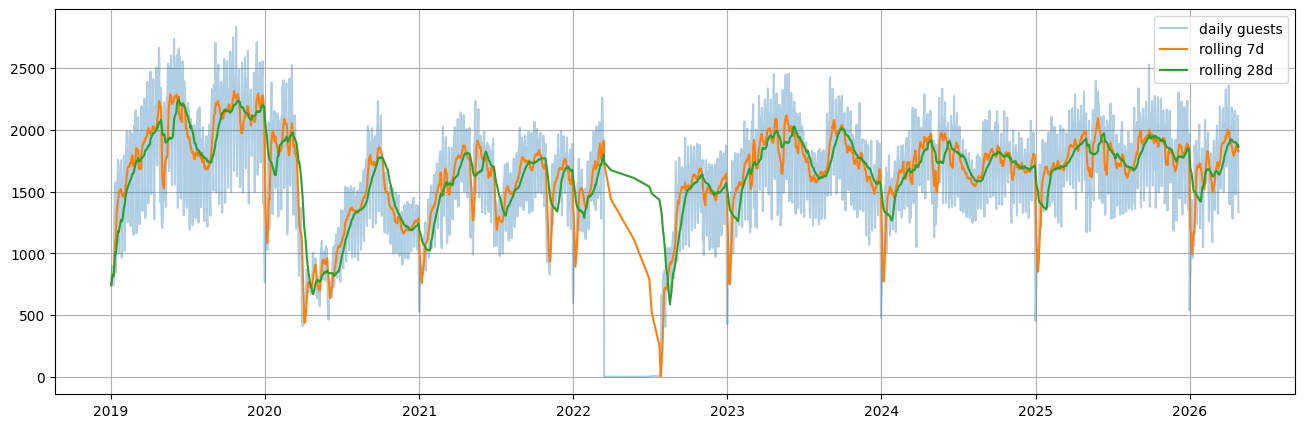

In [ ]:
daily = (
    df.groupby("sale_date", as_index=False)
    .agg(
        guests_sum=("guests_count", "sum"),
        guests_mean_hour=("guests_count", "mean"),
        zero_hours_share=("guests_count", lambda x: (x == 0).mean()),
        active_hours=("guests_count", lambda x: x.notna().sum()),
    )
)

daily["rolling_7"] = daily["guests_sum"].rolling(7, min_periods=1).mean()
daily["rolling_28"] = daily["guests_sum"].rolling(28, min_periods=1).mean()



plt.figure(figsize=(16, 5))
plt.plot(daily["sale_date"], daily["guests_sum"], alpha=0.35, label="daily guests")
plt.plot(daily["sale_date"], daily["rolling_7"], label="rolling 7d")
plt.plot(daily["sale_date"], daily["rolling_28"], label="rolling 28d")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
BAD_PERIODS = [
    ("2020-03-15", "2020-06-30", "covid_main_drop"),
    ("2020-07-01", "2020-08-31", "covid_recovery"),
    ("2021-06-28", "2021-07-18", "qr_restrictions"),
    ("2021-10-28", "2021-11-07", "oct_2021_non_working_days"),
    ("2022-03-08", "2022-06-11", "mcdonalds_suspended"),
    ("2022-06-12", "2022-08-31", "rebrand_ramp"),
]

df["period_type"] = "normal"

for start, end, name in BAD_PERIODS:
    mask = df["sale_date"].between(pd.Timestamp(start), pd.Timestamp(end))
    df.loc[mask, "period_type"] = name

df.loc[df["sale_date"] >= pd.Timestamp("2022-09-01"), "period_type"] = "post_rebrand_normal"



In [ ]:
period_stats = (
    df.groupby("period_type")
    .agg(
        rows=("guests_count", "size"),
        days=("sale_date", "nunique"),
        mean_guests=("guests_count", "mean"),
        median_guests=("guests_count", "median"),
        p10=("guests_count", lambda x: x.quantile(0.10)),
        p90=("guests_count", lambda x: x.quantile(0.90)),
        zero_share=("guests_count", lambda x: (x == 0).mean()),
        min_date=("sale_date", "min"),
        max_date=("sale_date", "max"),
    )
    .sort_values("mean_guests")
)

period_stats

,rows,days,mean_guests,median_guests,p10,p90,zero_share,min_date,max_date
period_type,,,,,,,,,
rebrand_ramp,552,38,54.237319,51.0,19.0,93.9,0.0,2022-06-30,2022-08-31
covid_main_drop,1719,108,55.038394,54.0,22.0,88.0,0.0,2020-03-15,2020-06-30
oct_2021_non_working_days,176,11,62.619318,62.5,31.0,88.0,0.0,2021-10-28,2021-11-07
qr_restrictions,336,21,77.577381,77.0,43.5,109.0,0.0,2021-06-28,2021-07-18
covid_recovery,992,62,84.964718,81.0,44.0,133.9,0.0,2020-07-01,2020-08-31
normal,15330,959,107.647358,103.0,50.0,170.0,0.0,2019-01-02,2022-03-07
post_rebrand_normal,21319,1334,107.809653,108.0,51.0,163.0,0.0,2022-09-01,2026-04-26
mcdonalds_suspended,119,10,112.579832,114.0,31.0,176.8,0.0,2022-03-08,2022-05-24


In [ ]:
reference = df[
    (df["sale_date"] >= pd.Timestamp("2022-09-01"))
    & (df["period_type"] == "post_rebrand_normal")
].copy()

In [ ]:
baseline_pattern = (
    reference
    .groupby(["day_of_week", "hour"], as_index=False)
    .agg(
        baseline_median=("guests_count", "median"),
        baseline_mean=("guests_count", "mean"),
    )
)

df_cmp = df.merge(
    baseline_pattern,
    on=["day_of_week", "hour"],
    how="left"
)

df_cmp["ratio_to_pattern"] = (
    df_cmp["guests_count"] / df_cmp["baseline_median"].clip(lower=1)
)

df_cmp["relative_error_vs_pattern"] = (
    (df_cmp["guests_count"] - df_cmp["baseline_median"]).abs()
    / df_cmp["baseline_median"].clip(lower=5)
)

period_pattern_stats = (
    df_cmp.groupby("period_type")
    .agg(
        rows=("guests_count", "size"),
        days=("sale_date", "nunique"),
        median_ratio_to_pattern=("ratio_to_pattern", "median"),
        mean_ratio_to_pattern=("ratio_to_pattern", "mean"),
        median_relative_error=("relative_error_vs_pattern", "median"),
        mean_relative_error=("relative_error_vs_pattern", "mean"),
        zero_share=("guests_count", lambda x: (x == 0).mean()),
    )
    .sort_values("median_ratio_to_pattern")
)

period_pattern_stats

,rows,days,median_ratio_to_pattern,mean_ratio_to_pattern,median_relative_error,mean_relative_error,zero_share
period_type,,,,,,,
rebrand_ramp,552,38,0.492409,0.483615,0.507591,0.516385,0.0
covid_main_drop,1719,108,0.496241,0.501505,0.503759,0.500052,0.0
oct_2021_non_working_days,176,11,0.599020,0.592819,0.400980,0.409747,0.0
qr_restrictions,336,21,0.718083,0.733813,0.282398,0.272726,0.0
covid_recovery,992,62,0.779979,0.783772,0.221331,0.222199,0.0
normal,15330,959,0.983051,0.986295,0.153285,0.186640,0.0
post_rebrand_normal,21319,1334,1.000000,0.991416,0.100671,0.131816,0.0
mcdonalds_suspended,119,10,1.161290,1.038604,0.231293,0.289179,0.0


In [ ]:
daily = (
    df.groupby("sale_date", as_index=False)
    .agg(
        guests_sum=("guests_count", "sum"),
        guests_mean_hour=("guests_count", "mean"),
        rows=("guests_count", "size"),
        min_hour=("hour", "min"),
        max_hour=("hour", "max"),
    )
)

daily["rolling_7"] = daily["guests_sum"].rolling(7, min_periods=1).mean()
daily["rolling_14"] = daily["guests_sum"].rolling(14, min_periods=1).mean()
daily["year"] = daily["sale_date"].dt.year
daily["month"] = daily["sale_date"].dt.month

In [ ]:
def plot_year_months(daily, year):
    part = daily[daily["year"] == year].copy()

    plt.figure(figsize=(18, 6))

    plt.plot(
        part["sale_date"],
        part["guests_sum"],
        alpha=0.35,
        label="daily guests"
    )

    plt.plot(
        part["sale_date"],
        part["rolling_7"],
        linewidth=2,
        label="rolling 7d"
    )

    plt.plot(
        part["sale_date"],
        part["rolling_14"],
        linewidth=2,
        label="rolling 14d"
    )

    # Вертикальные линии начала месяцев
    month_starts = pd.date_range(
        start=f"{year}-01-01",
        end=f"{year}-12-31",
        freq="MS"
    )

    for d in month_starts:
        plt.axvline(d, linestyle="--", alpha=0.25)
        plt.text(
            d,
            part["guests_sum"].max() * 1.02,
            d.strftime("%b"),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=9,
        )

    plt.title(f"Daily guests by month: {year}")
    plt.xlabel("date")
    plt.ylabel("daily guests")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

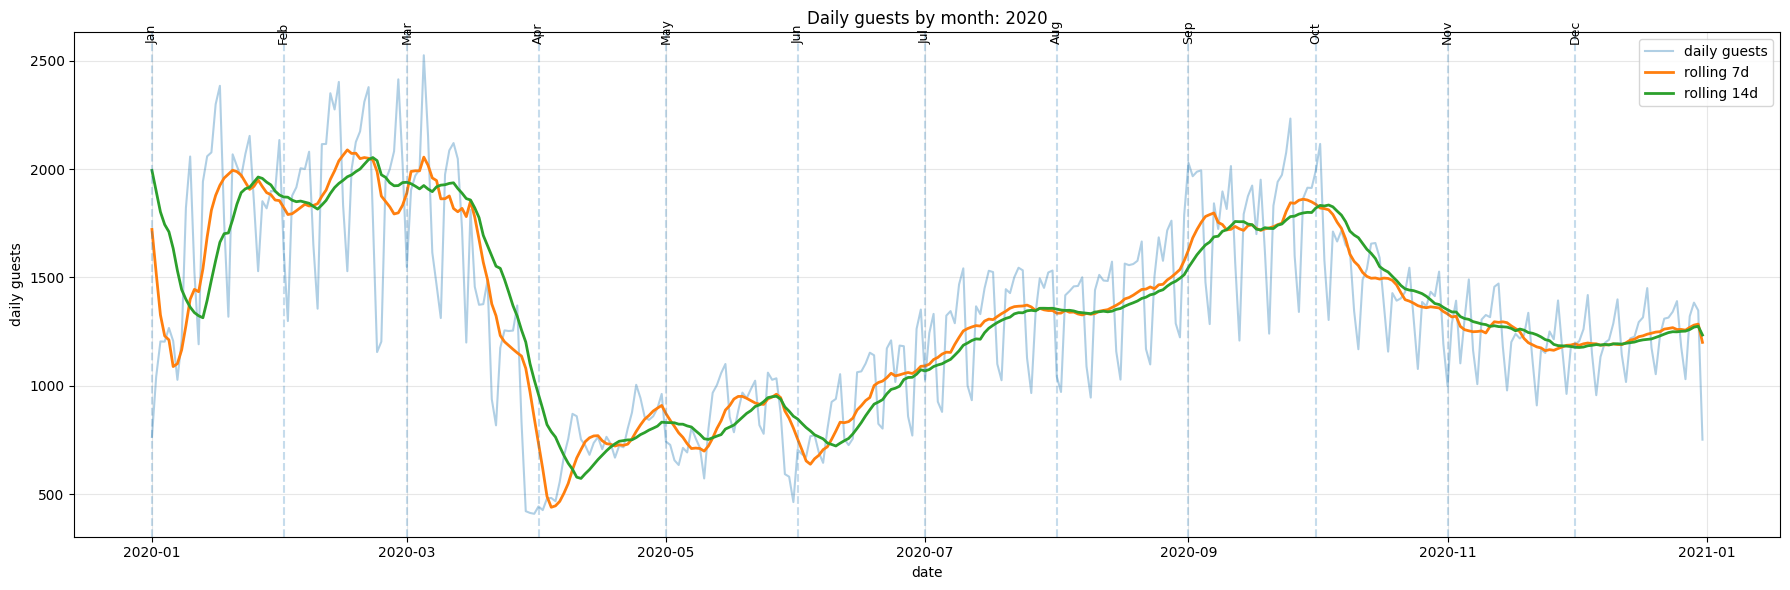

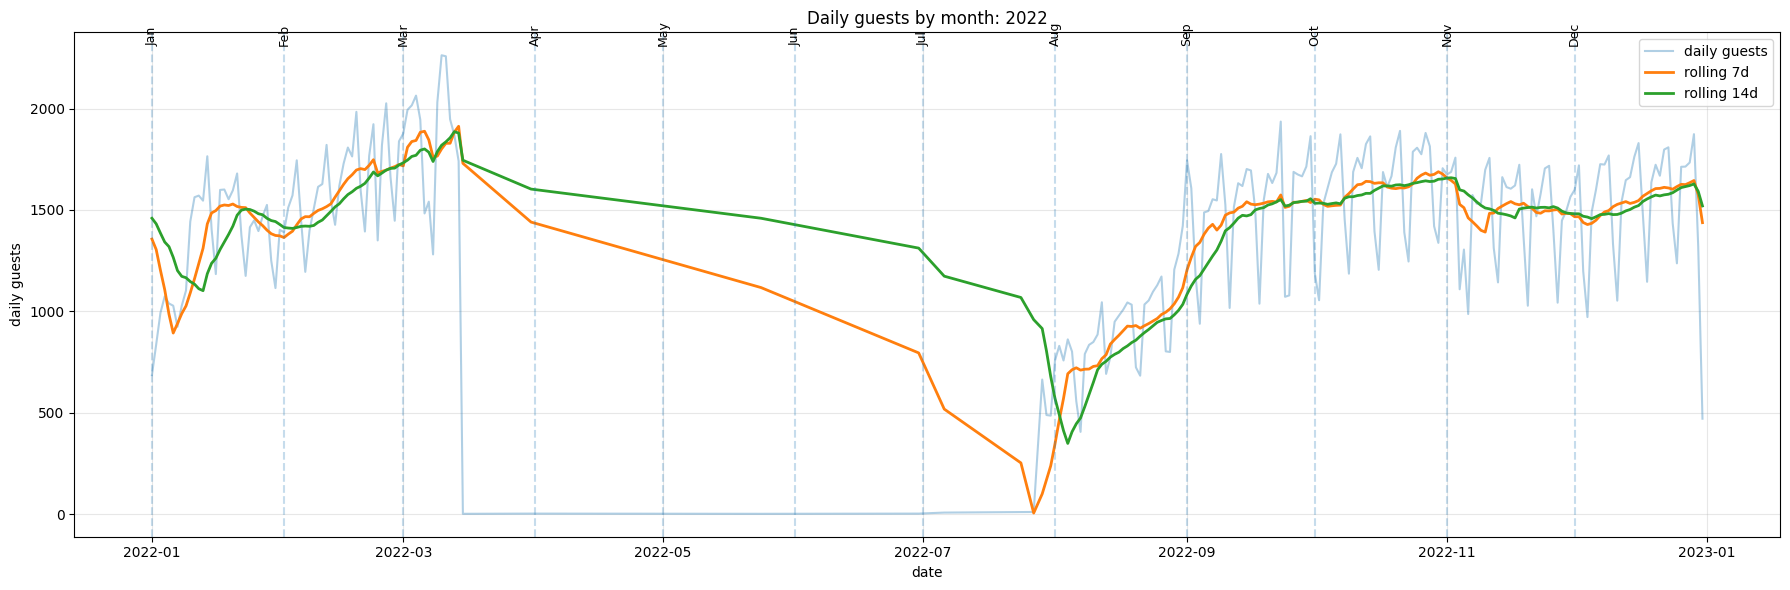

In [ ]:
plot_year_months(daily, 2020)
plot_year_months(daily, 2022)

In [ ]:
BAD_PERIODS_BY_YEAR = {
    2020: [
        ("2020-03-15", "2020-06-30", "covid main drop"),
        ("2020-07-01", "2020-08-31", "covid recovery"),
    ],
    2022: [
        ("2022-03-08", "2022-06-11", "mcdonalds suspended"),
        ("2022-06-12", "2022-08-31", "rebrand ramp"),
    ],
}

In [ ]:
def plot_year_months_with_periods(daily, year):
    part = daily[daily["year"] == year].copy()

    plt.figure(figsize=(18, 6))

    plt.plot(
        part["sale_date"],
        part["guests_sum"],
        alpha=0.35,
        label="daily guests"
    )

    plt.plot(
        part["sale_date"],
        part["rolling_7"],
        linewidth=2,
        label="rolling 7d"
    )

    plt.plot(
        part["sale_date"],
        part["rolling_14"],
        linewidth=2,
        label="rolling 14d"
    )

    # Подсветка плохих периодов
    for start, end, name in BAD_PERIODS_BY_YEAR.get(year, []):
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        plt.axvspan(start, end, alpha=0.15, label=name)

    # Вертикальные линии месяцев
    month_starts = pd.date_range(
        start=f"{year}-01-01",
        end=f"{year}-12-31",
        freq="MS"
    )

    y_max = part["guests_sum"].max()

    for d in month_starts:
        plt.axvline(d, linestyle="--", alpha=0.25)
        plt.text(
            d,
            y_max * 1.02,
            d.strftime("%b"),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=9,
        )

    plt.title(f"Daily guests by month with bad periods: {year}")
    plt.xlabel("date")
    plt.ylabel("daily guests")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

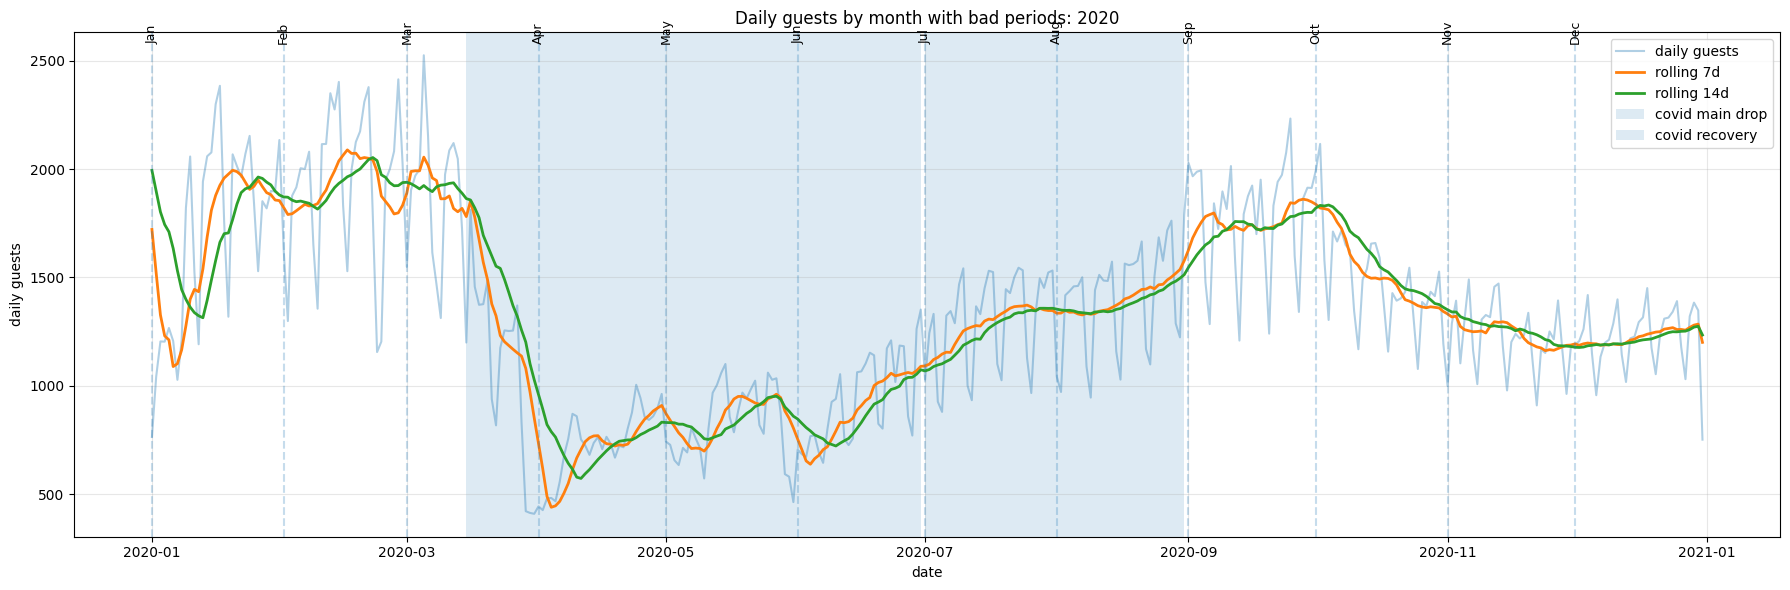

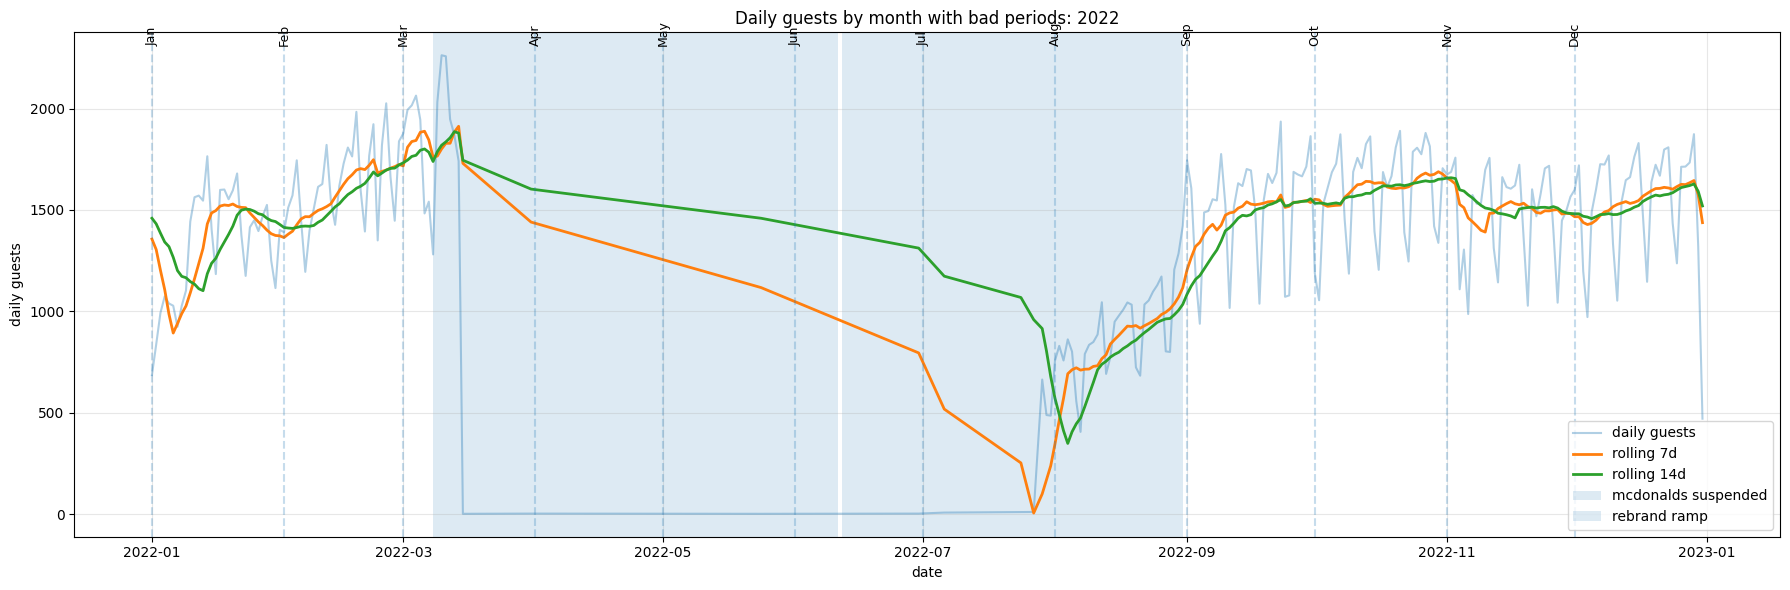

In [ ]:
plot_year_months_with_periods(daily, 2020)
plot_year_months_with_periods(daily, 2022)

In [ ]:
DROP_PERIODS = [
    "covid_main_drop",
    "covid_recovery",
    "qr_restrictions",
    "oct_2021_non_working_days",
    "rebrand_ramp",
    "mcdonalds_suspended",
]

clean_df = df_cmp[
    ~df_cmp["period_type"].isin(DROP_PERIODS)
].copy()

print("before:", len(df_cmp))
print("after:", len(clean_df))
print("removed:", len(df_cmp) - len(clean_df))
print("removed share:", 1 - len(clean_df) / len(df_cmp))

before: 40543
after: 36649
removed: 3894
removed share: 0.09604617319882591


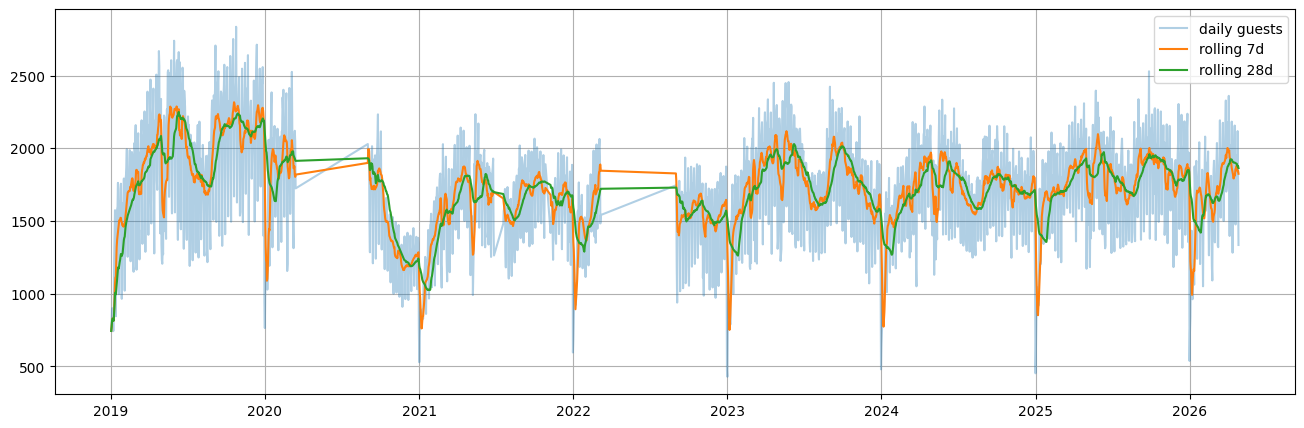

In [ ]:
daily = (
    clean_df.groupby("sale_date", as_index=False)
    .agg(
        guests_sum=("guests_count", "sum"),
        guests_mean_hour=("guests_count", "mean"),
        zero_hours_share=("guests_count", lambda x: (x == 0).mean()),
        active_hours=("guests_count", lambda x: x.notna().sum()),
    )
)

daily["rolling_7"] = daily["guests_sum"].rolling(7, min_periods=1).mean()
daily["rolling_28"] = daily["guests_sum"].rolling(28, min_periods=1).mean()



plt.figure(figsize=(16, 5))
plt.plot(daily["sale_date"], daily["guests_sum"], alpha=0.35, label="daily guests")
plt.plot(daily["sale_date"], daily["rolling_7"], label="rolling 7d")
plt.plot(daily["sale_date"], daily["rolling_28"], label="rolling 28d")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reference = clean_df[
    clean_df["sale_date"] >= pd.Timestamp("2022-09-01")
].copy()

baseline_pattern = (
    reference
    .groupby(["day_of_week", "hour"], as_index=False)
    .agg(
        baseline_median=("guests_count", "median"),
        baseline_mean=("guests_count", "mean"),
    )
)

clean_df = clean_df.drop(
    columns=["baseline_median", "baseline_mean"],
    errors="ignore"
)

clean_df = clean_df.merge(
    baseline_pattern,
    on=["day_of_week", "hour"],
    how="left"
)

clean_df["ratio_to_pattern"] = (
    clean_df["guests_count"] / clean_df["baseline_median"].clip(lower=1)
)

clean_df["relative_error_vs_pattern"] = (
    (clean_df["guests_count"] - clean_df["baseline_median"]).abs()
    / clean_df["baseline_median"].clip(lower=5)
)

In [ ]:
daily_clean = (
    clean_df.groupby("sale_date", as_index=False)
    .agg(
        guests_sum=("guests_count", "sum"),
        expected_sum=("baseline_median", "sum"),
        rows=("guests_count", "size"),
        min_hour=("hour", "min"),
        max_hour=("hour", "max"),
        zero_share=("guests_count", lambda x: (x == 0).mean()),
        median_relative_error=("relative_error_vs_pattern", "median"),
        mean_relative_error=("relative_error_vs_pattern", "mean"),
        median_ratio_to_pattern=("ratio_to_pattern", "median"),
    )
)

daily_clean["ratio_to_expected"] = (
    daily_clean["guests_sum"] / daily_clean["expected_sum"].clip(lower=1)
)

daily_clean["abs_daily_error"] = (
    daily_clean["guests_sum"] - daily_clean["expected_sum"]
).abs()

daily_clean["relative_daily_error"] = (
    daily_clean["abs_daily_error"] / daily_clean["expected_sum"].clip(lower=10)
)

In [ ]:
median_rows = daily_clean["rows"].median()

bad_days = daily_clean[
    (daily_clean["ratio_to_expected"] < 0.60)
    | (daily_clean["ratio_to_expected"] > 1.60)
    | (daily_clean["zero_share"] > 0.30)
    | (daily_clean["rows"] < median_rows * 0.70)
].copy()

bad_days = bad_days.sort_values("sale_date")

bad_days

,sale_date,guests_sum,expected_sum,rows,min_hour,max_hour,zero_share,median_relative_error,mean_relative_error,median_ratio_to_pattern,ratio_to_expected,abs_daily_error,relative_daily_error
0,2019-01-02,744,1850.5,16,7,22,0.0,0.559402,0.617574,0.440598,0.402053,1106.5,0.597947
1,2019-01-03,800,1887.0,16,7,22,0.0,0.541112,0.592738,0.458888,0.423953,1087.0,0.576047
2,2019-01-04,900,1988.0,16,7,22,0.0,0.508433,0.563916,0.491567,0.452716,1088.0,0.547284
3,2019-01-05,871,1559.5,16,7,22,0.0,0.437896,0.455918,0.562104,0.558512,688.5,0.441488
5,2019-01-07,743,1748.5,16,7,22,0.0,0.519278,0.587128,0.480722,0.424936,1005.5,0.575064
6,2019-01-08,830,1811.5,16,7,22,0.0,0.499711,0.560993,0.500289,0.458184,981.5,0.541816
363,2019-12-31,935,1740.5,15,7,21,0.0,0.389356,0.456465,0.610644,0.537202,805.5,0.462798
364,2020-01-01,764,1461.5,11,12,22,0.0,0.472119,0.454543,0.527881,0.522751,697.5,0.477249
365,2020-01-02,1042,1887.0,16,7,22,0.0,0.459021,0.462914,0.540979,0.552199,845.0,0.447801
370,2020-01-07,1028,1811.5,16,7,22,0.0,0.404908,0.441171,0.595092,0.567486,783.5,0.432514


In [ ]:
clean_df.to_csv("clean_guests.csv", index=False)

In [ ]:
train_df = clean_df.copy()

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])

train_df["sale_date"] = train_df["timestamp"].dt.date
train_df["sale_hour"] = train_df["timestamp"].dt.hour

train_df = train_df[["sale_date", "sale_hour", "guests_count"]]

train_df.to_csv("guests_clean.csv", index=False)

train_df.head()

,sale_date,sale_hour,guests_count
0,2019-01-02,7,5
1,2019-01-02,8,11
2,2019-01-02,9,14
3,2019-01-02,10,17
4,2019-01-02,11,28


In [ ]:
train_df.to_csv("clean_guests.csv", index=False)